In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import matplotlib.pyplot as plt

from src.data_loader import load_traffic_data
from src.data_overview import convert_timestamp
from src.preprocessing import (
    set_time_index,
    handle_missing_values,
    resample_daily,
    train_test_split
)
from src.forecasting import train_sarima_model
from src.anomaly import detect_anomalies


In [3]:
df = load_traffic_data()
df = convert_timestamp(df)
df = set_time_index(df)
df = handle_missing_values(df)

daily_df = resample_daily(df)

train_df, test_df = train_test_split(daily_df, test_days=30)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Train size: 89
Test size: 30


In [4]:
model = train_sarima_model(train_df)

print("Model trained successfully!")


Model trained successfully!


In [7]:
anomaly_results = detect_anomalies(model, test_df, threshold_multiplier=2)

anomaly_results.head()


,Actual,Predicted,Residual,Anomaly
Timestamp,,,,
2020-04-18,42188.0,102322.104439,-60134.104439,False
2020-04-19,42479.0,93486.102624,-51007.102624,False
2020-04-20,381563.0,356012.622944,25550.377056,False
2020-04-21,327789.0,323869.766958,3919.233042,False
2020-04-22,310868.0,311067.242299,-199.242299,False


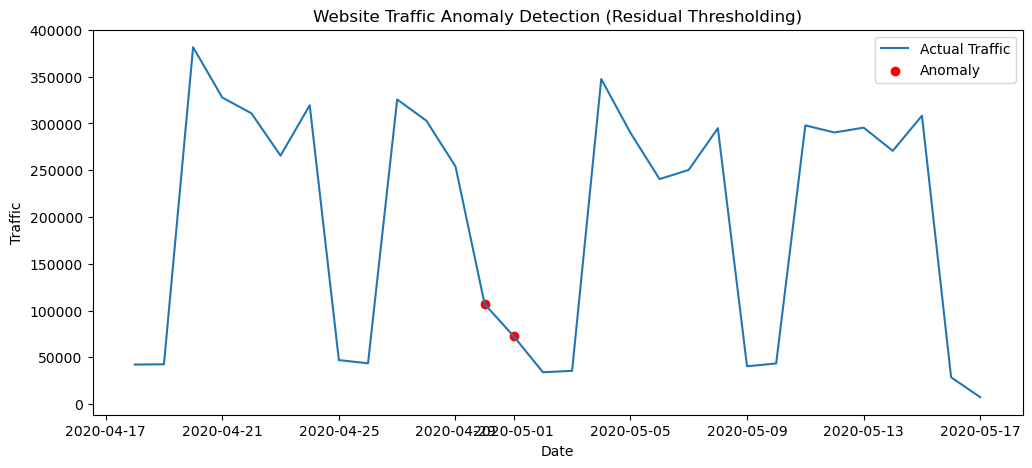

In [8]:
plt.figure(figsize=(12,5))

plt.plot(anomaly_results.index, anomaly_results["Actual"], label="Actual Traffic")

plt.scatter(
    anomaly_results[anomaly_results["Anomaly"]].index,
    anomaly_results[anomaly_results["Anomaly"]]["Actual"],
    color="red",
    label="Anomaly"
)

plt.legend()
plt.title("Website Traffic Anomaly Detection (Residual Thresholding)")
plt.xlabel("Date")
plt.ylabel("Traffic")
plt.show()
